# Project Overview
A group of customers bought the lastest generation of a smartwatch released by a technology company. The smartwatch keeps track of user activities on a daily basis and the collected information is sent to cloud servers. For this excercise, you will explore a dataset of user behavior activites (ueba.csv) collected in February 2023.
- import pandas as pd
- df = pd.read_csv('ueba.csv', parse_dates=['timestamp']) 


- Create visualizations to identify patterns in the data.
- Try to apply an outlier detection estimator to find users that exhibit unusual behavior compared to the population.

# Import Libraries

In [38]:
# standard
import numpy as np
import pandas as pd
import time

# plots
import matplotlib.pyplot as plt
import seaborn as sns

# other
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder, MinMaxScaler
from sklearn.ensemble import IsolationForest

# Get Data

In [2]:
df = pd.read_csv('ueba.csv', parse_dates=['timestamp']) 

In [3]:
df.head()

,timestamp,user,behavior
0,2023-02-01 10:48:26,Connor,awake
1,2023-02-01 00:30:43,Connor,asleep
2,2023-02-02 09:51:43,Connor,awake
3,2023-02-02 04:57:21,Connor,asleep
4,2023-02-03 15:10:42,Connor,awake


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 806400 entries, 0 to 806399
Data columns (total 3 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   timestamp  806400 non-null  datetime64[ns]
 1   user       806400 non-null  object        
 2   behavior   806400 non-null  object        
dtypes: datetime64[ns](1), object(2)
memory usage: 18.5+ MB


<Axes: >

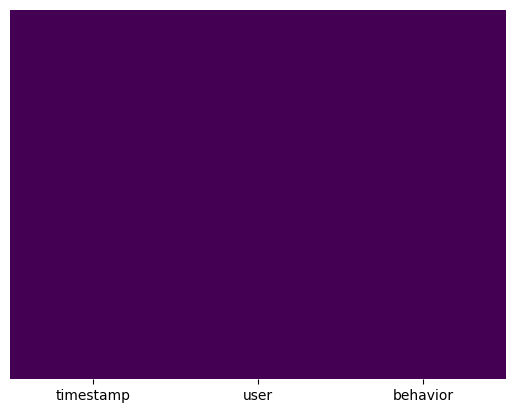

In [5]:
# Nulos
sns.heatmap(df.isnull(),yticklabels=False,cbar=False,cmap='viridis')

In [4]:
# Duplicados
print(f'Number of duplicated rows: {df.duplicated().sum()}')
df = df.drop_duplicates()
df.shape

Number of duplicated rows: 1831


(804569, 3)

# EDA

## Timestamp

In [15]:
df['timestamp'].min()

Timestamp('2023-02-01 00:00:00')

In [16]:
df['timestamp'].max()

Timestamp('2023-02-28 23:59:59')

## Behavior

In [14]:
df['behavior'].value_counts()

behavior
asleep    402291
awake     402278
Name: count, dtype: int64

## User

In [5]:
df['user'].value_counts()

user
George     8056
Sarah      8056
Kirsten    8055
Sherry     8054
Tyler      8053
           ... 
Michael    8037
Ashley     8037
Deborah    8037
Rhonda     8036
Phillip    8033
Name: count, Length: 100, dtype: int64

In [6]:
# Verifico que la cantidad de muestras por usuario sea más o menos la misma. Y lo es
df_aux = df.groupby(['user']).agg({'timestamp':['nunique']})
df_aux.columns = df_aux.columns.droplevel()
df_aux.reset_index().sort_values(by='nunique')

,user,nunique
72,Phillip,8033
53,Kimberly,8036
76,Rhonda,8036
9,Ashley,8037
63,Michael,8037
...,...,...
95,Tyler,8053
90,Taylor,8053
54,Kirsten,8055
37,George,8056


In [7]:
## Otra forma de ver esto: Veo cuantas mediciones de behavior tuvo cada usuario
display(df.groupby('user')['behavior'].count())

user
Aaron      8043
Adam       8041
Alan       8045
Alec       8048
Alex       8044
           ... 
Tyler      8053
Victor     8050
Wanda      8044
Whitney    8043
Zachary    8046
Name: behavior, Length: 100, dtype: int64

In [8]:
# Ahora quiero estudiar la frecuencia de muestreo. Observo que en medias y desviaciones standard los valores hacen suponer que hay un muestreo uniforme.
df_aux = df.sort_values(by=['user', 'timestamp'])
df_aux['time_diff'] = df_aux.groupby('user')['timestamp'].diff()
df_aux.groupby('user')['time_diff'].describe().sort_values(by=['mean','std'])

,count,mean,std,min,25%,50%,75%,max
user,,,,,,,,
Sarah,8055,0 days 00:05:00.281440099,0 days 00:07:57.068705389,0 days 00:00:01,0 days 00:01:05,0 days 00:02:45,0 days 00:05:45,0 days 02:47:23
Kirsten,8054,0 days 00:05:00.299975167,0 days 00:07:35.874735156,0 days 00:00:01,0 days 00:01:07,0 days 00:02:43,0 days 00:05:55,0 days 02:09:05
George,8055,0 days 00:05:00.319925512,0 days 00:07:50.594454514,0 days 00:00:01,0 days 00:01:05,0 days 00:02:40,0 days 00:05:50,0 days 02:04:47
Sherry,8053,0 days 00:05:00.370048429,0 days 00:07:35.224589223,0 days 00:00:00,0 days 00:01:04,0 days 00:02:41,0 days 00:05:56,0 days 02:04:11
Ruben,8051,0 days 00:05:00.398459818,0 days 00:07:57.941270559,0 days 00:00:01,0 days 00:01:04,0 days 00:02:37,0 days 00:05:37,0 days 01:51:05
...,...,...,...,...,...,...,...,...
Michael,8036,0 days 00:05:01.014310602,0 days 00:07:51.788741885,0 days 00:00:01,0 days 00:01:03,0 days 00:02:40,0 days 00:05:46,0 days 01:47:59
Deborah,8036,0 days 00:05:01.015803882,0 days 00:07:41.951331695,0 days 00:00:01,0 days 00:01:07,0 days 00:02:41,0 days 00:05:47,0 days 02:13:11
Ashley,8036,0 days 00:05:01.016177202,0 days 00:07:37.887519971,0 days 00:00:01,0 days 00:01:05,0 days 00:02:40,0 days 00:05:44,0 days 01:51:31


In [9]:
# Sin embargo, si miro mínimos y máximos, veo que existen muestreos que ocurrieron cada 1 hr 28 minutos hasta 3 hr 23 minutos.
df_aux.groupby('user')['time_diff'].describe().sort_values(by=['min','max'])

,count,mean,std,min,25%,50%,75%,max
user,,,,,,,,
Kevin,8039,0 days 00:05:00.895633785,0 days 00:07:33.094660106,0 days 00:00:00,0 days 00:01:03,0 days 00:02:39,0 days 00:05:52,0 days 01:28:31
Wanda,8043,0 days 00:05:00.724729578,0 days 00:07:38.232607064,0 days 00:00:00,0 days 00:01:05,0 days 00:02:41,0 days 00:05:44,0 days 01:42:26
Jennifer,8049,0 days 00:05:00.519319170,0 days 00:07:42.271633110,0 days 00:00:00,0 days 00:01:03,0 days 00:02:41,0 days 00:05:49,0 days 01:49:31
Jodi,8051,0 days 00:05:00.425288784,0 days 00:07:40.765050786,0 days 00:00:00,0 days 00:01:05,0 days 00:02:43,0 days 00:05:49,0 days 01:52:56
Sherry,8053,0 days 00:05:00.370048429,0 days 00:07:35.224589223,0 days 00:00:00,0 days 00:01:04,0 days 00:02:41,0 days 00:05:56,0 days 02:04:11
...,...,...,...,...,...,...,...,...
Keith,8047,0 days 00:05:00.582204548,0 days 00:07:53.565214989,0 days 00:00:01,0 days 00:01:04,0 days 00:02:42,0 days 00:05:48,0 days 02:54:39
Robin,8044,0 days 00:05:00.724515166,0 days 00:07:56.035690944,0 days 00:00:01,0 days 00:01:03,0 days 00:02:41,0 days 00:05:48,0 days 02:57:52
Julie,8048,0 days 00:05:00.550571570,0 days 00:08:15.554560350,0 days 00:00:01,0 days 00:01:03,0 days 00:02:35,0 days 00:05:46,0 days 03:07:42


## Normalización de mediciones

Los tiempos de las mediciones no son uniformes. Entonces, se redondean a 1 medición por hora para cada usuario. Se busca que sean comparables las mediciones entre los distintos usuarios. Por eso, lo que voy a hacer es:

- Resamplear los datos a 1hr. Acá voy a perder granularidad y no sabré que pasa en menos de 1hr. Asumo que esta es una hipótesis razonable a menos que quiera estudiar algún tipo de bug particular o trastornos del sueño muy específicos. 
- En ese resampleo, voy a contar la cantidad de awakes (despierto) y asleep (dormido).
- Sumo esos dos números, eso me da el total de mediciones en una hora.
- Luego, divido esas sumas por el total. Esto me da porcentaje de detecciones en una hora en que el usuario estuvo dormido y despierto. De este modo, me independizo un poco de los detalles del sampling dentro de esa hora.
- 1 hora es un valor arbitrario. Podría ser más, o menos. No voy a refinar este parámetro porque los resultados que obtuve así me parecen razonables a este nivel.

In [20]:
df['behaviorr'] = df['behavior'].replace({'awake': 0, 'asleep': 1})
df['timestampp'] = df['timestamp'].dt.round(freq='h')

df_normalized = df.groupby(['user','timestampp'], as_index = False)['behaviorr'].mean()

users = df_normalized['user'].unique()

/tmp/ipykernel_2450/975409665.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['behaviorr'] = df['behavior'].replace({'awake': 0, 'asleep': 1})


In [21]:
df_normalized.head()

,user,timestampp,behaviorr
0,Aaron,2023-02-01 00:00:00,1.0
1,Aaron,2023-02-01 01:00:00,1.0
2,Aaron,2023-02-01 02:00:00,1.0
3,Aaron,2023-02-01 03:00:00,1.0
4,Aaron,2023-02-01 04:00:00,1.0


In [23]:
users

array(['Aaron', 'Adam', 'Alan', 'Alec', 'Alex', 'Alexis', 'Angela',
       'Anthony', 'April', 'Ashley', 'Belinda', 'Bobby', 'Bradley',
       'Brandon', 'Brian', 'Brianna', 'Bridget', 'Brooke', 'Carlos',
       'Caroline', 'Cathy', 'Cheryl', 'Christopher', 'Clinton', 'Connor',
       'Craig', 'Dana', 'Danielle', 'David', 'Deborah', 'Denise',
       'Destiny', 'Devin', 'Donald', 'Doris', 'Edward', 'Gary', 'George',
       'James', 'Janet', 'Jenna', 'Jennifer', 'Jill', 'Jodi', 'Joe',
       'John', 'Jonathan', 'Joseph', 'Julie', 'Justin', 'Karen', 'Keith',
       'Kevin', 'Kimberly', 'Kirsten', 'Latoya', 'Laura', 'Leah', 'Lisa',
       'Luis', 'Mark', 'Matthew', 'Melissa', 'Michael', 'Nancy', 'Nathan',
       'Nicholas', 'Pamela', 'Patricia', 'Patrick', 'Pedro', 'Penny',
       'Phillip', 'Rachel', 'Reginald', 'Renee', 'Rhonda', 'Richard',
       'Robert', 'Robin', 'Ruben', 'Samuel', 'Sandra', 'Sarah', 'Sean',
       'Sherry', 'Sonya', 'Stephanie', 'Steven', 'Tanya', 'Taylor',
       'T

In [19]:
df.head()

,timestamp,user,behavior,hora,fecha,behaviorr,timestampp
0,2023-02-01 10:48:26,Connor,awake,10:48:26,2023-02-01,0,2023-02-01 11:00:00
1,2023-02-01 00:30:43,Connor,asleep,00:30:43,2023-02-01,1,2023-02-01 01:00:00
2,2023-02-02 09:51:43,Connor,awake,09:51:43,2023-02-02,0,2023-02-02 10:00:00
3,2023-02-02 04:57:21,Connor,asleep,04:57:21,2023-02-02,1,2023-02-02 05:00:00
4,2023-02-03 15:10:42,Connor,awake,15:10:42,2023-02-03,0,2023-02-03 15:00:00


# Create visualizations to identify patterns in the data.

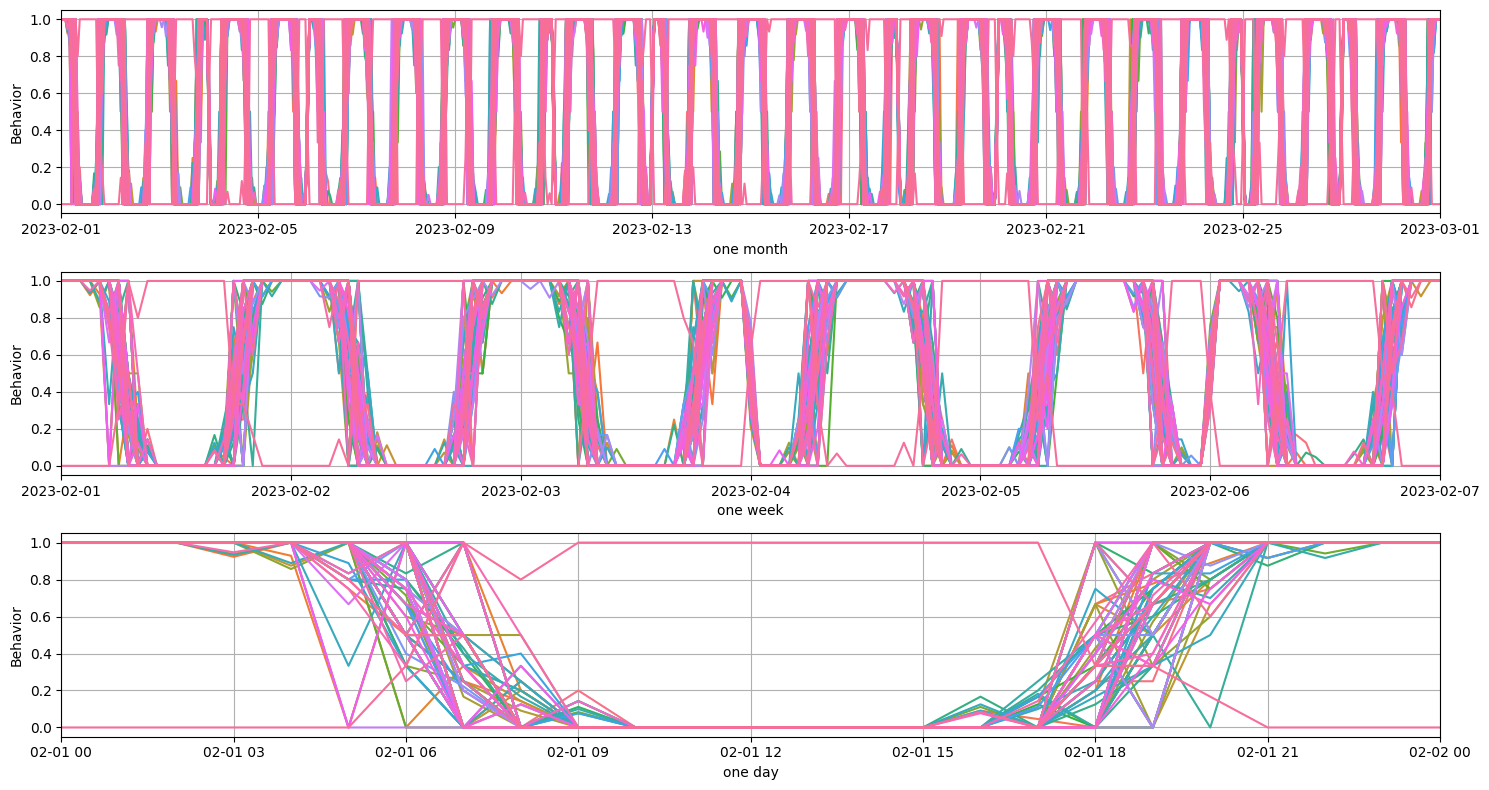

In [27]:
fig, axes = plt.subplots(3, 1, figsize=(15, 8))

for i, (interval, xlim) in enumerate([("one month", (df.timestampp.min(), df.timestampp.max())),
                                      ("one week", (pd.Timestamp("2023-02-01"), pd.Timestamp("2023-02-07"))),
                                      ("one day", (pd.Timestamp("2023-02-01"), pd.Timestamp("2023-02-02")))]):
    ax = sns.lineplot(data=df_normalized, x='timestampp', y='behaviorr', hue='user', ax=axes[i], legend=False)
    ax.set_xlabel(interval)
    ax.set_ylabel('Behavior')
    ax.set_xlim(xlim)
    ax.grid(True)

plt.tight_layout()
plt.show()

# Try to apply an outlier detection estimator to find users that exhibit unusual behavior compared to the population.

Para determinar un estimador de outlier es necesario ver el comportamiento de cada usuario, es el motivo por el cual se modifica la estructura del df original. El fin es tener una fila por usuario con el valor promedio de actividad por hora, sin distinción de día.

In [28]:
df_pivot2 = df_normalized.pivot_table(index='user', columns='timestampp', values='behaviorr').reset_index()
df_pivot2.head()

timestampp,user,2023-02-01 00:00:00,2023-02-01 01:00:00,2023-02-01 02:00:00,2023-02-01 03:00:00,2023-02-01 04:00:00,2023-02-01 05:00:00,2023-02-01 06:00:00,2023-02-01 07:00:00,2023-02-01 08:00:00,...,2023-02-28 15:00:00,2023-02-28 16:00:00,2023-02-28 17:00:00,2023-02-28 18:00:00,2023-02-28 19:00:00,2023-02-28 20:00:00,2023-02-28 21:00:00,2023-02-28 22:00:00,2023-02-28 23:00:00,2023-03-01 00:00:00
0,Aaron,1.0,1.0,1.0,1.0,1.0,1.0,1.000000,0.0,0.0,...,0.0,0.0,0.0,0.00,0.80,0.666667,1.0,1.0,1.0,1.0
1,Adam,1.0,1.0,1.0,1.0,1.0,1.0,1.000000,0.0,0.0,...,0.0,0.0,NaN,0.00,0.50,0.888889,1.0,1.0,1.0,1.0
2,Alan,1.0,1.0,1.0,1.0,1.0,1.0,0.666667,0.0,0.0,...,0.0,0.0,0.0,0.25,1.00,1.000000,1.0,1.0,1.0,1.0
3,Alec,1.0,1.0,1.0,1.0,1.0,1.0,0.750000,0.0,0.0,...,0.0,0.0,0.0,0.00,0.75,1.000000,1.0,1.0,1.0,1.0
4,Alex,1.0,1.0,1.0,1.0,1.0,1.0,0.750000,0.0,0.0,...,0.0,0.0,0.0,0.00,0.75,1.000000,1.0,1.0,1.0,1.0


*En la exploración de datos se detectó que no todos los usuarios tienen al menos una medición por hora.*

In [29]:
df = df.sort_values(by=['user', 'timestampp'])
df[(df['user']=='Adam') & (df['timestampp']>= pd.Timestamp('2023-02-28 16:00:00'))].head(10)

,timestamp,user,behavior,hora,fecha,behaviorr,timestampp
35502,2023-02-28 15:56:02,Adam,awake,15:56:02,2023-02-28,0,2023-02-28 16:00:00
97102,2023-02-28 16:16:34,Adam,awake,16:16:34,2023-02-28,0,2023-02-28 16:00:00
276302,2023-02-28 16:13:41,Adam,awake,16:13:41,2023-02-28,0,2023-02-28 16:00:00
298702,2023-02-28 15:36:46,Adam,awake,15:36:46,2023-02-28,0,2023-02-28 16:00:00
304302,2023-02-28 15:42:47,Adam,awake,15:42:47,2023-02-28,0,2023-02-28 16:00:00
416302,2023-02-28 16:10:25,Adam,awake,16:10:25,2023-02-28,0,2023-02-28 16:00:00
629102,2023-02-28 15:45:08,Adam,awake,15:45:08,2023-02-28,0,2023-02-28 16:00:00
724302,2023-02-28 15:54:47,Adam,awake,15:54:47,2023-02-28,0,2023-02-28 16:00:00
746702,2023-02-28 16:09:41,Adam,awake,16:09:41,2023-02-28,0,2023-02-28 16:00:00
248302,2023-02-28 17:37:08,Adam,awake,17:37:08,2023-02-28,0,2023-02-28 18:00:00


*Esto genera valores faltantes en df_pivot, para solucionarlo se imputa con 0 ('awake'), debido a que se considera que la mayor parte del día los usuarios estarán despiertos. Si esto no fuera satisfactorio, se implementaría otro método de imputación a futuro.*

In [30]:
df_pivot2 = df_pivot2.fillna(0)
df_pivot2.head()

timestampp,user,2023-02-01 00:00:00,2023-02-01 01:00:00,2023-02-01 02:00:00,2023-02-01 03:00:00,2023-02-01 04:00:00,2023-02-01 05:00:00,2023-02-01 06:00:00,2023-02-01 07:00:00,2023-02-01 08:00:00,...,2023-02-28 15:00:00,2023-02-28 16:00:00,2023-02-28 17:00:00,2023-02-28 18:00:00,2023-02-28 19:00:00,2023-02-28 20:00:00,2023-02-28 21:00:00,2023-02-28 22:00:00,2023-02-28 23:00:00,2023-03-01 00:00:00
0,Aaron,1.0,1.0,1.0,1.0,1.0,1.0,1.000000,0.0,0.0,...,0.0,0.0,0.0,0.00,0.80,0.666667,1.0,1.0,1.0,1.0
1,Adam,1.0,1.0,1.0,1.0,1.0,1.0,1.000000,0.0,0.0,...,0.0,0.0,0.0,0.00,0.50,0.888889,1.0,1.0,1.0,1.0
2,Alan,1.0,1.0,1.0,1.0,1.0,1.0,0.666667,0.0,0.0,...,0.0,0.0,0.0,0.25,1.00,1.000000,1.0,1.0,1.0,1.0
3,Alec,1.0,1.0,1.0,1.0,1.0,1.0,0.750000,0.0,0.0,...,0.0,0.0,0.0,0.00,0.75,1.000000,1.0,1.0,1.0,1.0
4,Alex,1.0,1.0,1.0,1.0,1.0,1.0,0.750000,0.0,0.0,...,0.0,0.0,0.0,0.00,0.75,1.000000,1.0,1.0,1.0,1.0


*Para estimar los outliers se utilizará un modelos de clusterización. En este problema se desconoce la cantidad de clusters, motivo por el cual se obta por Model DBScan. Así mismo, se tendrá que determinar el hiper-parámetro epsilon.*

In [31]:
df_pivot2.columns = df_pivot2.columns.astype('str')
columns_list = df_pivot2.columns.tolist()
columns_list = [item for item in columns_list if item != 'user']

In [33]:
neigh = NearestNeighbors(n_neighbors=2)
nbrs = neigh.fit(df_pivot2[columns_list])
distances, indices = nbrs.kneighbors(df_pivot2[columns_list])

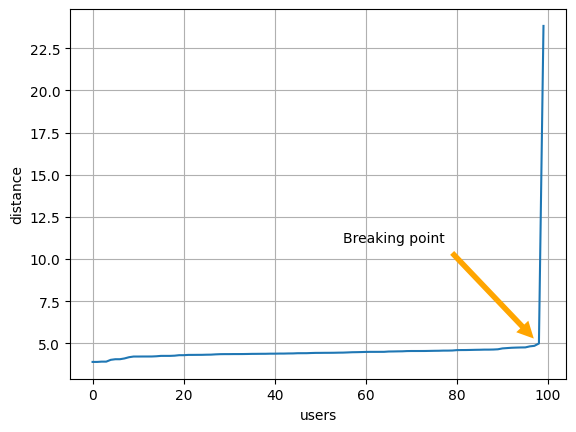

In [34]:
sorted_distances = sorted(distances[:,1])
plt.plot(sorted_distances)

plt.annotate('Breaking point', xy=(97.9, 5), xytext=(55, 11),
             arrowprops=dict(facecolor='orange', edgecolor='none', shrink=0.05))

plt.ylabel('distance')
plt.xlabel('users')
plt.grid()
plt.show()

*En el gráfico, se observa que hasta epsilon igual 5 se tienen muchos usuarios cerca con muy poca diferencia en la distancia. Apartir del breaking point, tener más usuarios implica un aumento mayor en la distancia*

In [35]:
dbscan = DBSCAN(eps=5, min_samples=5)
dbscan.fit(df_pivot2[columns_list])
df_pivot2['Outlier'] = dbscan.labels_

In [37]:
outlier = df_pivot2.loc[df_pivot2['Outlier'] == -1]

print(f'The outliers users are: {outlier.user.tolist()}')

The outliers users are: ['Whitney']


*Observación: la cantidad de columnas que se utilizaron puede hacer crecer la dimensionalidad de los datos, lo que puede repercutir en la performance del modelo. En tal caso, se puede reducir a sólo 24 columnas (24 horas) en las cuales se promedie la actividad total para ese mismo horario.*

## Otra forma 

## Normalización de mediciones

In [17]:
# Hago el resampling contando asleep y awake.
df1 = df.groupby([pd.Grouper(freq='H', key='timestamp'), 'user', 'behavior']).size().unstack(fill_value=0).reset_index()
df1.columns = ['timestamp', 'user', 'asleep', 'awake']
df1.head(3)

/tmp/ipykernel_2450/3963402493.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df1 = df.groupby([pd.Grouper(freq='H', key='timestamp'), 'user', 'behavior']).size().unstack(fill_value=0).reset_index()


,timestamp,user,asleep,awake
0,2023-02-01,Aaron,23,0
1,2023-02-01,Adam,25,0
2,2023-02-01,Alan,25,0


In [24]:
# Calculo la columna suma y divido
df1['asleep+awake'] = df1['asleep'] + df1['awake']
df1['asleep'] = df1['asleep']/df1['asleep+awake']
df1['awake'] = df1['awake']/df1['asleep+awake']
df1.head(3)

,timestamp,user,asleep,awake,asleep+awake
0,2023-02-01,Aaron,1.0,0.0,23
1,2023-02-01,Adam,1.0,0.0,25
2,2023-02-01,Alan,1.0,0.0,25


In [25]:
# Hago algunas observaciones y verificaciones
# A lo largo de una hora, el usuario puede estar como mucho el 100% de la hora despierto o dormido. No puede haber valores mayores a uno, tampoco negativos 
print(df1['asleep'].max())
print(df1['asleep'].min())
print(df1['awake'].max())
print(df1['awake'].min())

1.0
0.0
1.0
0.0


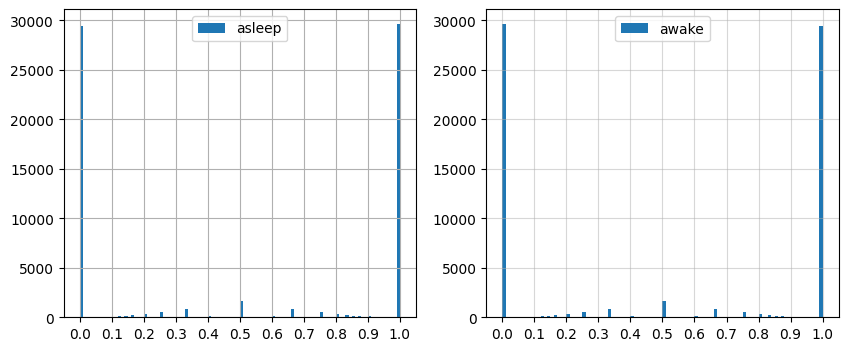

In [26]:
# También verifico que en el transcurso de una hora, la mayoría de las detecciones son 0% despierto/dormido, o 100% despierto/dormido. 
# Esto también respalda la elección de 1hr como resolución mínima.
fig, ax = plt.subplots(figsize=(10,4), ncols=2, dpi=100)
df1['asleep'].hist(bins=100, ax=ax[0], legend='asleep')
df1['awake'].hist(bins=100, ax=ax[1], legend='awake')
plt.grid(alpha=0.5)
ax[0].set_xticks(np.arange(0,1.1,0.1))
ax[1].set_xticks(np.arange(0,1.1,0.1))
plt.legend()

# Create visualizations to identify patterns in the data.

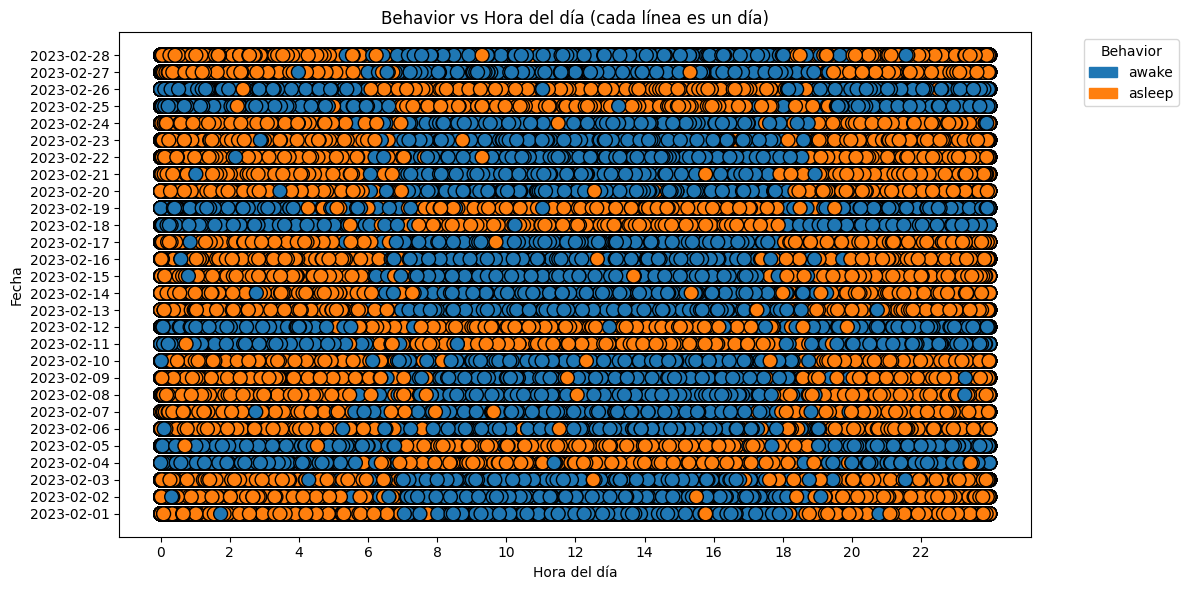

In [13]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['hora'] = df['timestamp'].dt.time
df['fecha'] = df['timestamp'].dt.date

behaviors = df['behavior'].unique()
color_map = {behavior: color for behavior, color in zip(behaviors, plt.cm.tab10.colors)}

fig, ax = plt.subplots(figsize=(12,6))

for fecha, group in df.groupby("fecha"):
    ax.scatter(
        group['timestamp'].dt.hour + group['timestamp'].dt.minute/60,
        [fecha]*len(group),
        c=group['behavior'].map(color_map),
        edgecolor='k',
        label=str(fecha) if fecha == df['fecha'].unique()[0] else "",
        s=100
    )

# Etiquetas y leyenda
ax.set_xlabel('Hora del día')
ax.set_ylabel('Fecha')
ax.set_yticks(sorted(df["fecha"].unique()))
ax.set_xticks(range(0,24,2))
# Crear leyenda de comportamientos
import matplotlib.patches as mpatches
legend_handles = [mpatches.Patch(color=color_map[b], label=b) for b in behaviors]
plt.legend(handles=legend_handles, title="Behavior", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title("Behavior vs Hora del día (cada línea es un día)")
plt.tight_layout()
plt.show()

In [39]:
# Voy a usar un algorítmo llamado IsolationForest para detectar anomalías en los datos. No es la única forma de hacerlo pero pensé 
# que era una de las más prolijas y eficientes. Por supuesto, al menos hasta cierto punto, voy a respaldar los resultados con los 
# gráficos correspondientes. 

# Comienzo construyendo los features.
features = df1[['timestamp', 
               'user', 
               'asleep',
               'awake']]


features['timestamp'] = features['timestamp'].apply(lambda x: x.timestamp())            # Convierto los timestamps a números.
features['user'] = features['user'].astype('category').cat.codes                        # Convierto los nombres de usuario a números.


# Utilizo MinMaxScaler para reescalar los datos. Aunque en este caso no es necesario, resulta siempre una buena práctica.
scaler = MinMaxScaler()
features = pd.DataFrame(scaler.fit_transform(features), columns=features.columns)

# Preparo el modelo
model = IsolationForest(random_state = 19091987,                                        # Siempre uso mi fecha de nacimiento.
                        contamination=0.01)                                             # Elijo el modelo. La contamicación la fui ajustando a lo largo de 
                                                                                        # las iteraciones
model.fit(features)

# Creo dos columnas, una que dice qué puntos son outliers (-1 outliers, 1 no outlier) y otra que dice que scoring tiene ese outlier (más negativo es "mas outlier")
df1['outlier'] = model.predict(features)
df1['scoring'] = model.decision_function(features)


/tmp/ipykernel_2450/3622100351.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  features['timestamp'] = features['timestamp'].apply(lambda x: x.timestamp())            # Convierto los timestamps a números.
/tmp/ipykernel_2450/3622100351.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  features['user'] = features['user'].astype('category').cat.codes                        # Convierto los nombres de usuario a números.


# Try to apply an outlier detection estimator to find users that exhibit unusual behavior compared to the population.

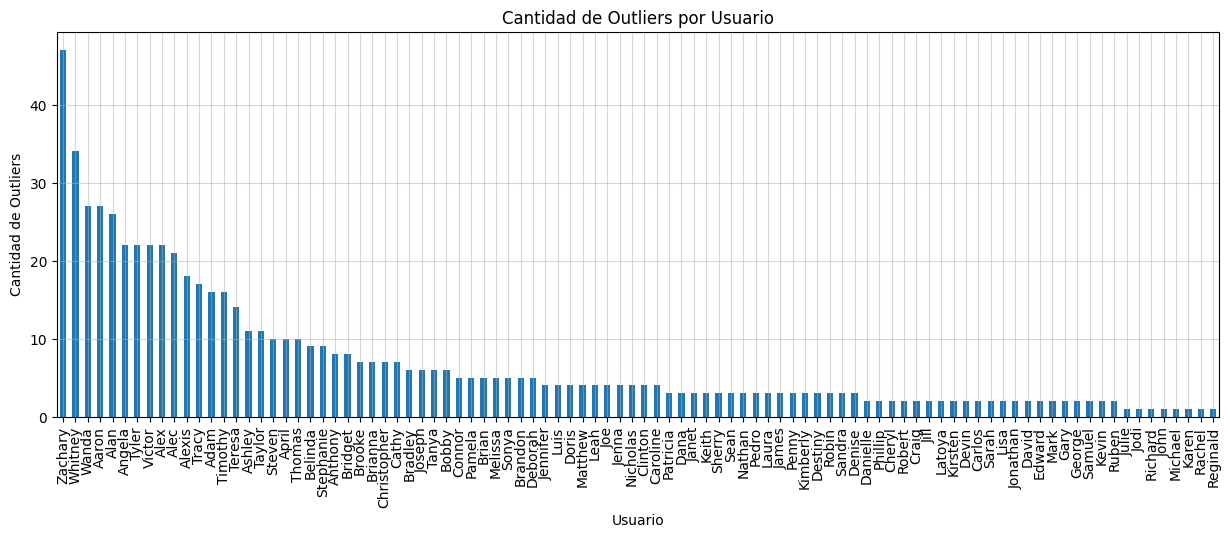

In [40]:
# Fijo como criterio que los usuarios más extraños son los que tienen más outliers. Esto tranquilamente se podría cuestionar.
# Observo que destacan Zachary y Whitney por sobre todos los demás. 
outliers_count = df1[df1['outlier'] == -1]['user'].value_counts()
plt.figure(figsize=(15, 5), dpi=100)
outliers_count.plot(kind='bar')
plt.title('Cantidad de Outliers por Usuario')
plt.xlabel('Usuario')
plt.ylabel('Cantidad de Outliers')
plt.grid(alpha=0.5)
plt.show()

/tmp/ipykernel_2450/3270881195.py:8: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(0,1e5)


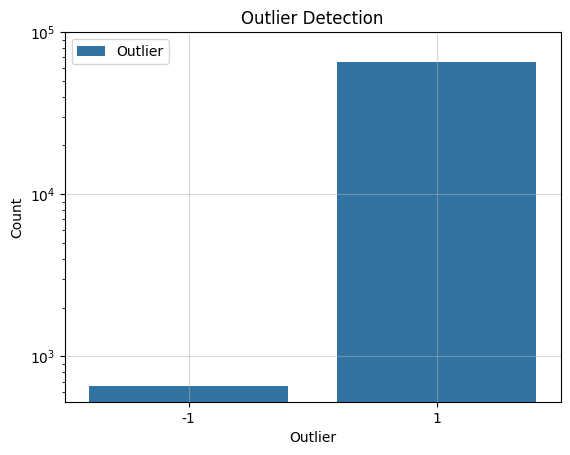

In [41]:
# Esta es una representación de la cantidad de valores atípicos que existen en los datos
sns.countplot(x='outlier', data=df1, label='Outlier')
plt.title('Outlier Detection')
plt.xlabel('Outlier')
plt.ylabel('Count')
plt.grid(alpha=0.5)
plt.yscale('log')
plt.ylim(0,1e5)
plt.legend()
plt.show()

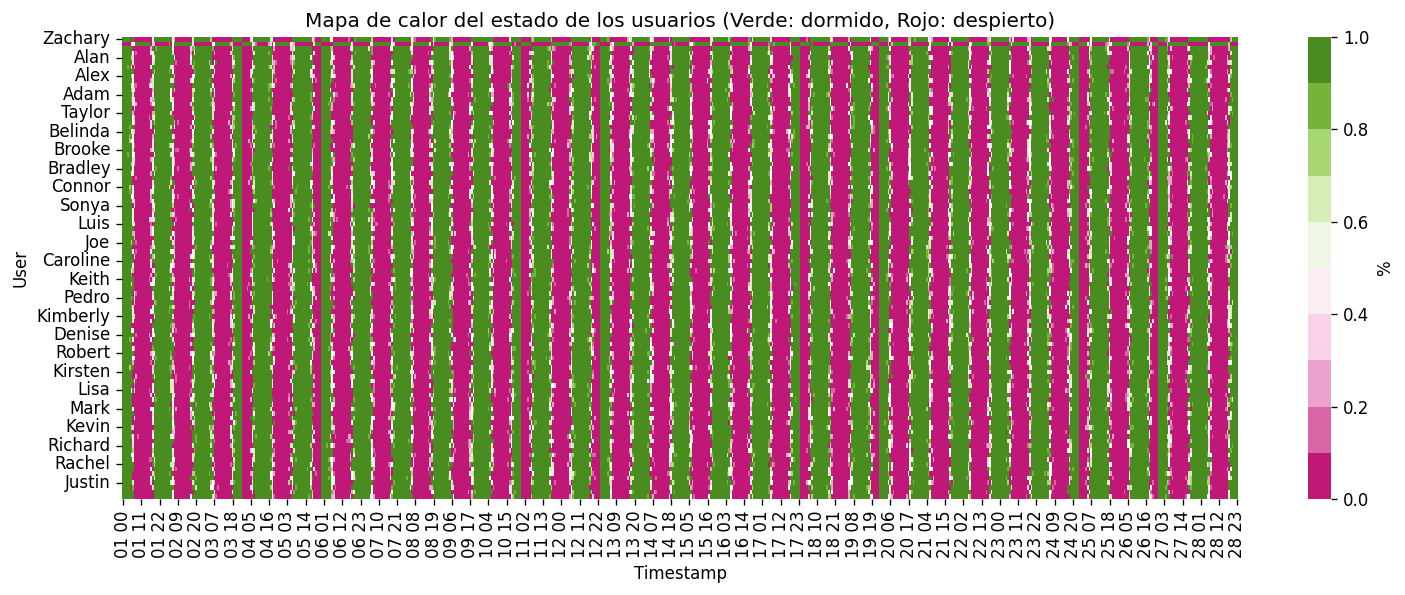

In [42]:
# Y este es el apartado donde trato de mostrar por qué los usuarios outlier de hecho lo son. Voy a hacer un mapa de calor que muestre 
# para cada usuario y cada hora el porcentaje de 'asleep' (dormido). Es un plot complejo pero a mi criterio bastante gráfico.

# Voy a poner arriba de todo los usuarios 'outlier', ordenados como aparecieron en el gráfico anterior. Luego muestro el resto.
orden_indices = outliers_count.index.tolist() + list(set(df1['user'].unique()) - set(outliers_count.index.tolist()))

# Voy a hacer un heatmap con una paleta PiYG y 10 niveles (10%, 20%, etc)
colormap = sns.color_palette("PiYG", 10) 

# El heatmap lo genero apartir de pivotear el dataframe. 'sum' en este caso no hace nada porque no hay que agrupar por usuario y timestamp, ya está agrupado.
# Lo uso solo para cambiar la forma de la matriz. 
heatmap_data = df1.pivot_table(index='user', columns='timestamp', values='asleep', aggfunc='sum')
heatmap_data = heatmap_data.reindex(orden_indices)

# Corrijo el formato de la fecha
date_format = "%d %H:%M:%S"
heatmap_data.columns = heatmap_data.columns.strftime('%d %H')

# Creo el mapa de calor
plt.figure(figsize=(15, 5), dpi=120)
sns.heatmap(heatmap_data, 
            cmap=colormap,
            cbar_kws={'label': '%'})
plt.title('Mapa de calor del estado de los usuarios (Verde: dormido, Rojo: despierto)')
plt.xlabel('Timestamp')
plt.ylabel('User')
plt.show()

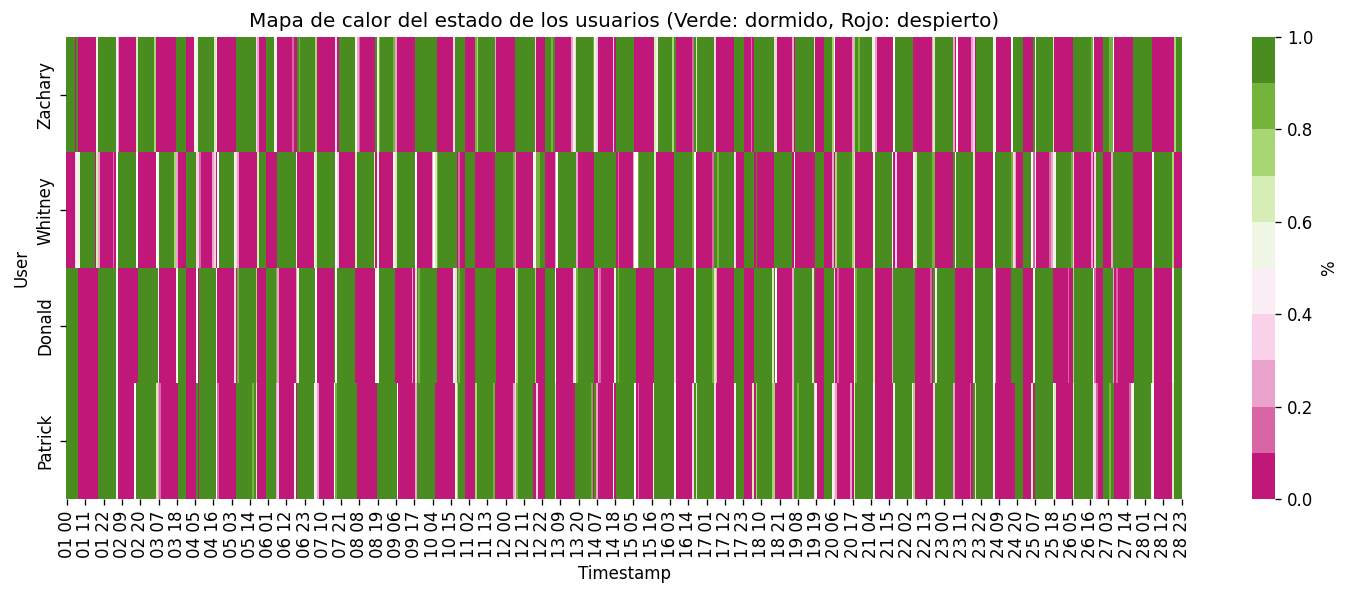

In [43]:
# Voy a copypastear el mismo código pero quedándome con los primeros tres índices y los tres últimos (2 muy outliers y 2 normales)

orden_indices = outliers_count.index.tolist() + list(set(df['user'].unique()) - set(outliers_count.index.tolist()))
orden_indices = orden_indices[:2] + orden_indices[-2:]
colormap = sns.color_palette("PiYG", 10) 

heatmap_data = df1.pivot_table(index='user', columns='timestamp', values='asleep', aggfunc='sum')
heatmap_data = heatmap_data.reindex(orden_indices)

date_format = "%d %H:%M:%S"
heatmap_data.columns = heatmap_data.columns.strftime('%d %H')

plt.figure(figsize=(15, 5), dpi=120)
sns.heatmap(heatmap_data, 
            cmap=colormap,
            cbar_kws={'label': '%'})
plt.title('Mapa de calor del estado de los usuarios (Verde: dormido, Rojo: despierto)')
plt.xlabel('Timestamp')
plt.ylabel('User')
plt.show()

Conclusiones "trazo grueso" a simple vista:

- Zachary: parecería tener muchas franjas blancas envolviendo a franjas verdes, y en ubicaciones temporales en las que otros usuarios no tienen. Esto significa que antes y después de dormir hay intervalos en los que está un rato despierto y un rato dormido. No voy a hacer doble click por simplicidad, pero una conclusión definitiva lo requiere.

- Whitney: este comportamiento, a pesar de aparecer segundo en este modelito, es el más anómalo, probablemente hasta sea un fake o una inversión awake-asleep de los datos originales. Siempre que todos los usuarios duermen, Whitney está despierta; y a la inversa, siempre que todos los usuarios están despiertos, Whitney duerme. 